# Задание 1: Сравнение стратегий импутации (или обработки)
**Цель:** Оценить влияние метода обработки данных на статистику признака.
**Инструкция:**
1.  Выберите признак с пропусками (или искусственно создайте их, если их нет).
2.  Заполните пропуски двумя разными способами (например, Среднее vs Медиана, или Удаление строк vs Заполнение).
3.  Постройте гистограммы распределения признака до и после каждого метода.
4.  Рассчитайте, как изменилось среднее и стандартное отклонение.
5.  **Вывод:** Какой метод меньше исказил исходное распределение?

> **Подсказка:** Используйте `df.describe()` до и после операций. Для продвинутых: попробуйте `IterativeImputer` из `sklearn.impute`.

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [34]:
# Загрузка данных
california = fetch_california_housing()
df = pd.DataFrame(california.data, columns=california.feature_names)
df['Target'] = california.target

In [35]:
np.random.seed(42)

In [36]:
# Создаем пропуски (5% случайно)
missing_cols = ['AveRooms', 'AveBedrms', 'Population']
for col in missing_cols:
    mask = np.random.choice([True, False], size=len(df), p=[0.05, 0.95])
    df.loc[mask, col] = np.nan

In [37]:
# Создаем категориальный признак (возраст дома)
df['HouseAgeCat'] = pd.cut(df['HouseAge'],
                           bins=[0, 10, 30, 50, 100],
                           labels=['New', 'Medium', 'Old', 'VeryOld'])

In [38]:
# Создаем выбросы в целевой переменной
df.loc[np.random.choice(df.index, 10), 'Target'] = df['Target'].max() * 5

In [39]:
column_to_impute = 'AveRooms'
df_original = df.copy()

In [40]:
# Копирование для различных методов импутации
df_mean_imputed = df.copy()
df_median_imputed = df.copy()

In [41]:
# Заполнение средним значением
mean_value = df_mean_imputed[column_to_impute].mean()
df_mean_imputed[column_to_impute] = df_mean_imputed[column_to_impute].fillna(mean_value)

In [42]:
# Заполнение медианой
median_value = df_median_imputed[column_to_impute].median()
df_median_imputed[column_to_impute] = df_median_imputed[column_to_impute].fillna(median_value)

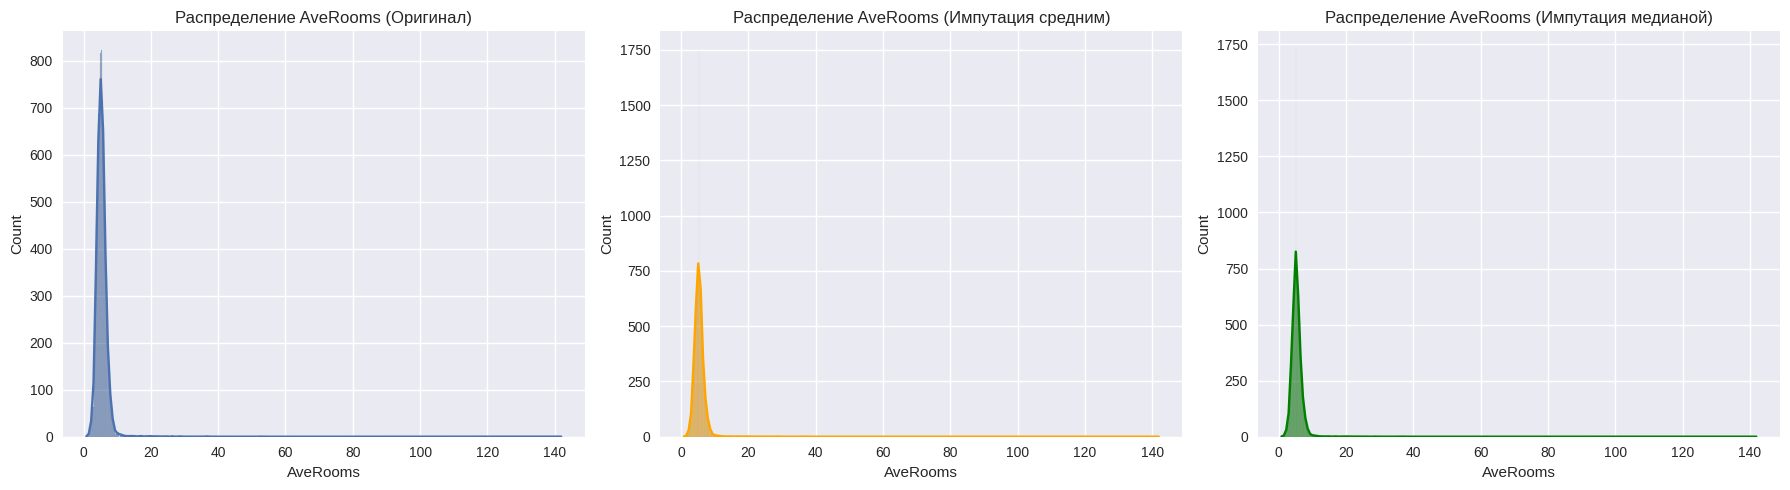

In [43]:
# Построение гистограмм
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
sns.histplot(df_original[column_to_impute].dropna(), kde=True)
plt.title(f"Распределение {column_to_impute} (Оригинал)")

plt.subplot(1, 3, 2)
sns.histplot(df_mean_imputed[column_to_impute], kde=True, color='orange')
plt.title(f"Распределение {column_to_impute} (Импутация средним)")

plt.subplot(1, 3, 3)
sns.histplot(df_median_imputed[column_to_impute], kde=True, color='green')
plt.title(f"Распределение {column_to_impute} (Импутация медианой)")

plt.tight_layout()
plt.show()

## Статистика для AveRooms

In [45]:
print("Оригинал (без пропусков):\n", df_original[column_to_impute].dropna().describe())

Оригинал (без пропусков):
 count    19622.000000
mean         5.431698
std          2.506290
min          0.846154
25%          4.442583
50%          5.230603
75%          6.053573
max        141.909091
Name: AveRooms, dtype: float64


In [46]:
print("\nПосле импутации средним:\n", df_mean_imputed[column_to_impute].describe())


После импутации средним:
 count    20640.000000
mean         5.431698
std          2.443698
min          0.846154
25%          4.490504
50%          5.310036
75%          5.999059
max        141.909091
Name: AveRooms, dtype: float64


In [47]:
print("\nПосле импутации медианой:\n", df_median_imputed[column_to_impute].describe())


После импутации медианой:
 count    20640.000000
mean         5.421780
std          2.444086
min          0.846154
25%          4.490504
50%          5.230603
75%          5.999059
max        141.909091
Name: AveRooms, dtype: float64


## ВЫВОДЫ:
- Заполнение медианой оказалось лучше для 'AveRooms'. Хотя оба метода изменили данные не сильно, медиана более устойчива к выбросам. Это значит, что медиана меньше искажает изначальную форму распределения данных.

- Поскольку в 'AveRooms' были замечены выбросы (очень большие значения), медиана помогла сохранить более реалистичную картину распределения. Если бы мы использовали среднее, эти выбросы могли бы сильнее 'потянуть' его за собой, сильнее изменив данные.

# Задание 2: Детекция и визуализация выбросов
Цель: Научиться находить и аргументированно удалять аномалии. Инструкция:

Выберите числовой признак, наиболее важный для вашей задачи (по корреляции с таргетом).
Найдите выбросы методом IQR и методом Z-Score.
Визуализуйте их на Boxplot и Scatterplot (подсветите выбросы красным цветом).
Посчитайте процент выбросов от общего числа данных.
Вывод: Стоит ли удалять эти строки или они содержат ценную информацию (например, дорогие дома или редкие случаи болезни)?
Подсказка: Если выбросов > 5%, удаление может привести к потере информации. Рассмотрите возможность "обрезки" (capping) значений вместо удаления.

In [57]:
df_numeric = df.select_dtypes(include=[np.number])
correlation_with_target = df_numeric.corr()['Target'].abs().sort_values(ascending=False)

In [58]:
# КАК ТУТ СДЕЛАТЬ ПЕРЕНОС СТРОКИ??? PEP8
feature_to_check = correlation_with_target.index[1] if correlation_with_target.index[0] == 'Target' else correlation_with_target.index[0]

In [62]:
# КОД ВЗЯТ С САЙТА https://ru.python-3.com/?p=3622

def detect_outliers_iqr(data_series):
    Q1 = data_series.quantile(0.25)
    Q3 = data_series.quantile(0.75)
    IQR = Q3 - Q1
    outliers_mask = (data_series < Q1 - 1.5 * IQR) | (data_series > Q3 + 1.5 * IQR)
    return outliers_mask

def detect_outliers_zscore(data_series, threshold=3):
    mean = data_series.mean()
    std = data_series.std()
    z_scores = np.abs((data_series - mean) / std)
    outliers_mask = z_scores > threshold
    return outliers_mask

In [63]:
outliers_iqr_mask = detect_outliers_iqr(df[feature_to_check])
outliers_zscore_mask = detect_outliers_zscore(df[feature_to_check])

num_outliers_iqr = outliers_iqr_mask.sum()
num_outliers_zscore = outliers_zscore_mask.sum()

print(f"\nКоличество выбросов в '{feature_to_check}' (метод IQR): {num_outliers_iqr}")
print(f"Количество выбросов в '{feature_to_check}' (метод Z-Score): {num_outliers_zscore}")


Количество выбросов в 'MedInc' (метод IQR): 681
Количество выбросов в 'MedInc' (метод Z-Score): 345


In [64]:
total_samples = len(df)
percent_outliers_iqr = (num_outliers_iqr / total_samples) * 100
percent_outliers_zscore = (num_outliers_zscore / total_samples) * 100

print(f"Процент выбросов (метод IQR): {percent_outliers_iqr:.2f}%")
print(f"Процент выбросов (метод Z-Score): {percent_outliers_zscore:.2f}%")

Процент выбросов (метод IQR): 3.30%
Процент выбросов (метод Z-Score): 1.67%


Text(0, 0.5, 'MedInc')

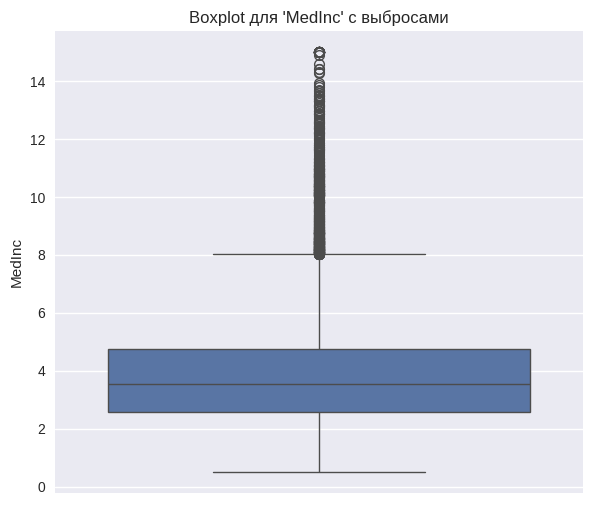

In [67]:
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.boxplot(y=df[feature_to_check])
plt.title(f"Boxplot для '{feature_to_check}' с выбросами")
plt.ylabel(feature_to_check)

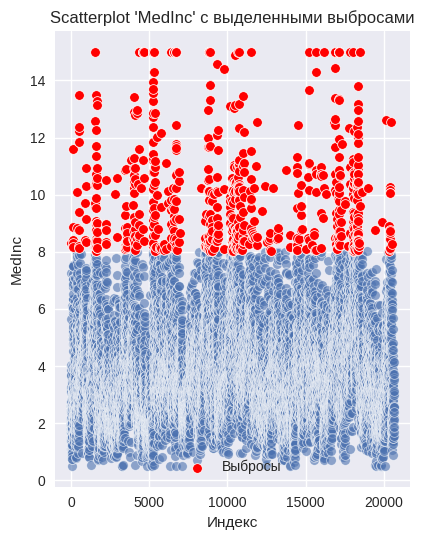

In [78]:
plt.subplot(1, 2, 2)
sns.scatterplot(x=df.index, y=df[feature_to_check], alpha=0.6)

outliers_combined_mask = outliers_iqr_mask | outliers_zscore_mask
sns.scatterplot(x=df[outliers_combined_mask].index, y=df[outliers_combined_mask][feature_to_check], color='red', label='Выбросы')
plt.title(f"Scatterplot '{feature_to_check}' с выделенными выбросами")
plt.xlabel("Индекс")
plt.ylabel(feature_to_check)
plt.legend()

plt.tight_layout()
plt.show()

In [77]:
print(f"Для признака '{feature_to_check}' обнаружено {percent_outliers_iqr:.2f}%")
print(f"выбросов по IQR и {percent_outliers_zscore:.2f}% по Z-Score (с порогом 3).")
print(f"Оба метода указывают на наличие значительного количества аномалий.")

Для признака 'MedInc' обнаружено 3.30%
выбросов по IQR и 1.67% по Z-Score (с порогом 3).
Оба метода указывают на наличие значительного количества аномалий.


## ВЫВОД:
Для признака 'MedInc' обнаружено 3.30% выбросов по IQR и 1.67% по Z-Score.
Процент выбросов относительно мал. Можно рассмотреть удаление этих строк, так как это не приведет к значительной потере данных. Однако, всегда стоит проверить, не являются ли эти выбросы важными данными (например, очень дорогие дома), которые могут содержать ценную информацию для модели.